# Phase 1 main experiment (part 1h): is the decorrelated regime *reachable* on real CICIDS, or is it degenerate?

**Where this comes from.** 07g confirmed the identifiability mechanism on synthetic data:
with a clean, proxy-free target (rho=0) aux-SHAP recovers the relevant set perfectly
(precision 1.000) and degrades monotonically as proxies strengthen (-> 0.533 at rho=0.99),
KS pinned at chance throughout. That is solid. But its **real** decorrelated arm is
invalid: `mean aux_recall = nan` — the eval label had a single class, so the model never
learned and its 0.067 precision is noise, not evidence about SHAP. The auto-verdict
`MECHANISM-HOLDS-SYNTH-ONLY` ("a second factor breaks real low-redundancy features")
therefore over-reads a broken construction.

**Why it broke — the confound.** The label is built as `X @ w > median`. On CICIDS the
features with the *lowest* redundancy are low-redundancy precisely *because* they are
near-constant (flag counts / rare-event counters that are 0 for almost every flow). Those
have near-zero correlation with everything **and** produce a near-constant score, hence a
degenerate, unlearnable label. So low redundancy and distributional degeneracy are
confounded: the features you *can* decorrelate are exactly the pathological ones. 07g's
real-low arm tested an unlearnable target.

**What 07h does — closing run.**
1. **Degeneracy diagnostic** — per-feature modal fraction and distinct-value count.
   Reproduce 07g's exact lowest-redundancy set, show its label balance, and demonstrate
   why recall was NaN.
2. **Non-degeneracy filter** — keep only features that are both well-behaved (modal
   fraction below a threshold, enough distinct values) and ask the decisive reachability
   question: *among non-degenerate features, is there a set of size k with external
   leakage <= 0.20?* i.e. does a decorrelated-AND-informative feature set exist on CICIDS
   at all.
3. **Corrected real arm** — select the lowest- and highest-redundancy sets **from the
   non-degenerate features only** (varying correlation, holding non-degeneracy fixed), run
   the concept arm, gate on aux-recall + label balance, and measure SHAP recovery only
   where the construction is valid.

**Pre-registered outcomes (D024).**
- *COMPOUND-STRUCTURAL-BLOCK* — no decorrelated non-degenerate set exists (the
  non-degenerate features are all mutually collinear). Then localization fails on CICIDS
  for a compound, measurable reason: informative features are collinear (non-identifiable)
  and decorrelated features are degenerate (unlearnable). Strongest structural statement;
  the positive search is closed with a two-dimensional diagnostic (redundancy AND
  distributional health).
- *REAL-POSITIVE-POLE* — a decorrelated non-degenerate set exists and SHAP recovers there
  (valid recall). A genuine real-data positive regime survives.
- *GENUINE-SECOND-FACTOR* — a decorrelated non-degenerate set exists, the model learns it
  (valid recall), yet SHAP still fails. Only here is "a second factor on real data"
  supported — and it would partially qualify the synthetic mechanism.

This is the last clarifying run: after it the picture is complete regardless, and the next
step is record-cleaning (annotate F011) + breadth. 07g's record stands as the audit trail.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap

import time, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score

from src.data.loaders import load_cicids2017
from src.utils.seeding import set_global_seed
from src.utils.documentation import log_finding, add_journal_entry
from src.divergence.localization import (
    shap_importance, ks_drift_scores, topk_indices, precision_at_k,
    random_precision_expectation,
)

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase1_07h_degeneracy.json'
G_JSON = ROOT / 'data' / 'processed' / 'phase1_07g_decorrelated_limit.json'
for p in (FIGURES, TABLES):
    p.mkdir(parents=True, exist_ok=True)

with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    meta06 = json.load(f)
FEATURE_COLS = meta06['feature_columns']
CONSTANT_FEATURES = meta06['constant_features_dropped']
RF_PARAMS = meta06['rf_hyperparameters']
N_FEATURES = len(FEATURE_COLS)

# carry the 07g synthetic mechanism result for the record (mechanism already confirmed there)
try:
    with open(G_JSON) as f:
        G = json.load(f)
    SYN_LOW_07G, SYN_TREND_07G = G.get('syn_low'), G.get('syn_trend')
    MECH_07G = bool(G.get('mechanism_confirmed'))
except Exception:
    SYN_LOW_07G = SYN_TREND_07G = None; MECH_07G = True
print(f'{N_FEATURES} real features. 07g synthetic mechanism confirmed: {MECH_07G} '
      f'(rho=0 SHAP={SYN_LOW_07G}, trend={SYN_TREND_07G})')

PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6, 'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)
METHOD_COLOR = {'aux_shap': '#E69F00', 'ks': '#0072B2', 'random': '#000000'}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png'); fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='07h_degeneracy_diagnostic'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.'); return
    entry = (f'\n## {decision_id} \u2014 {today}\n**Context:** `{context}`\n\n'
             f'**Decision:** {decision}\n\n**Rationale:** {rationale}\n\n')
    if alternatives:
        entry += f'**Alternatives considered:** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as f:
        f.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

print('Setup complete.')

82 real features. 07g synthetic mechanism confirmed: True (rho=0 SHAP=1.0, trend=0.4666666666666667)
Setup complete.


## 2. D024 — the degeneracy diagnostic, the non-degeneracy-controlled real arm, and the gate

07g's real-low arm confounded correlation with distributional degeneracy and returned NaN
recall. D024 isolates the variable of interest by holding non-degeneracy fixed and varying
only external correlation, and gates every real number on construction validity (learnable
label). The gate is committed before execution.

In [3]:
log_decision(
    decision_id='D024',
    decision=(
        'Resolve 07g\'s invalid real-low arm (NaN recall). (1) Compute per-feature '
        'degeneracy metrics (modal fraction, distinct-value count) and reproduce 07g\'s '
        'lowest-redundancy set to demonstrate its degenerate, unlearnable label. '
        '(2) Define non-degenerate features (modal fraction <= MODAL_MAX and distinct '
        'values >= MIN_DISTINCT) and ask the decisive reachability question: among '
        'non-degenerate features, does a set of size k exist with external leakage <= 0.20 '
        '(a decorrelated AND informative set)? (3) Corrected real arm: select lowest- and '
        'highest-redundancy sets FROM THE NON-DEGENERATE FEATURES ONLY (vary correlation, '
        'hold non-degeneracy fixed), run the concept arm, and measure aux-SHAP recovery, '
        'gating each arm on aux-recall >= RECALL_MIN and label balance in [0.2, 0.8]. '
        'Pre-registered outcomes (committed before execution): '
        'COMPOUND-STRUCTURAL-BLOCK iff no non-degenerate set reaches leakage <= 0.20 '
        '(decorrelated features are degenerate, informative features are collinear). '
        'REAL-POSITIVE-POLE iff a non-degenerate decorrelated set exists with valid recall '
        'and aux-SHAP precision >= 0.50. GENUINE-SECOND-FACTOR iff such a set exists with '
        'valid recall but aux-SHAP precision < 0.50 (clean target, learned model, SHAP '
        'still fails). The synthetic mechanism is already confirmed in 07g.'
    ),
    rationale=(
        '07g could not distinguish "real decorrelated features fail SHAP" from "the only '
        'real decorrelated features are degenerate and unlearnable". The non-degeneracy '
        'filter both removes the confound and fixes the label-balance problem (a median '
        'split on a non-degenerate feature is ~50/50 by construction), so any surviving '
        'failure is interpretable. The reachability question is the crux: if no '
        'decorrelated-and-informative set exists, the positive regime is structurally '
        'unreachable on CICIDS, and that is the finding.'
    ),
    alternatives=(
        'Re-run 07g real-low unchanged (rejected: degenerate label, uninterpretable). '
        'Rebalance the degenerate label artificially (rejected: would test a contrived '
        'target unrelated to how the feature behaves in practice). Synthetic only '
        '(rejected: 07g already settled the mechanism; the open question is real-data '
        'reachability).'
    ),
)

[DECISION LOGGED] D024


## 3. Configuration

`REL_SIZE = 5`, `precision@5`. `MODAL_MAX` / `MIN_DISTINCT` define non-degeneracy; counts
are reported at several thresholds so the choice is transparent. Real arms are interpreted
only when `aux_recall >= RECALL_MIN` and label balance lies in `BALANCE_BAND`.

In [4]:
set_global_seed(42)

N_POOL = 40000
ARM_N = 8000
REL_SIZE = 5
GT_SIZE = REL_SIZE
K_PRIMARY = REL_SIZE
SHAP_SAMPLE = 1500
SEEDS = [42, 1, 7]
RED_THRESHOLDS = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
MODAL_MAX = 0.90          # non-degenerate iff most-common raw value covers <= 90% of rows
MIN_DISTINCT = 20         # and at least this many distinct values
MODAL_GRID = [0.80, 0.90, 0.95, 0.99]   # reported for transparency
REAL_DECORR_MAX = 0.20    # a set is 'decorrelated' iff external leakage <= this
RECOVER_MIN = 0.50        # SHAP recovery bar
RECALL_MIN = 0.70         # construction-validity gate: label must be learnable
BALANCE_BAND = (0.2, 0.8) # construction-validity gate: label balance
METHODS = ['aux_shap', 'ks', 'random']
CHANCE = random_precision_expectation(GT_SIZE, N_FEATURES)

print(f'Chance precision@{K_PRIMARY} = {CHANCE:.3f}  |  GT_SIZE={GT_SIZE} of {N_FEATURES}')
print(f'Non-degenerate iff modal_fraction <= {MODAL_MAX} and distinct >= {MIN_DISTINCT}.')
print(f'Real arm interpreted iff aux_recall >= {RECALL_MIN} and balance in {BALANCE_BAND}.')
print(f'COMPOUND-STRUCTURAL-BLOCK iff no non-degenerate set reaches leakage <= {REAL_DECORR_MAX}.')

Chance precision@5 = 0.061  |  GT_SIZE=5 of 82
Non-degenerate iff modal_fraction <= 0.9 and distinct >= 20.
Real arm interpreted iff aux_recall >= 0.7 and balance in (0.2, 0.8).
COMPOUND-STRUCTURAL-BLOCK iff no non-degenerate set reaches leakage <= 0.2.


## 4. Real feature pool, correlation, and per-feature degeneracy

`REDUNDANCY[i]` = feature *i*'s strongest |corr| to any other feature. `MODAL_FRAC[i]` =
fraction of rows at *i*'s most common raw value (high = near-constant). `N_DISTINCT[i]` =
distinct raw values. Degeneracy is a raw-distribution property, so these are computed on
the unstandardised values.

In [5]:
X_raw, _, _ = load_cicids2017(day='monday')
X_raw = X_raw.drop(columns=CONSTANT_FEATURES, errors='ignore')[FEATURE_COLS]
idx = np.random.default_rng(42).choice(len(X_raw), size=min(N_POOL, len(X_raw)), replace=False)
Xp = X_raw.iloc[idx].to_numpy(dtype=float)         # raw (for degeneracy)
mu, sd = Xp.mean(0), Xp.std(0); sd[sd == 0] = 1.0
POOL = (Xp - mu) / sd                               # standardised (for modelling)

C = np.abs(np.corrcoef(POOL, rowvar=False)); np.fill_diagonal(C, 0.0); C = np.nan_to_num(C)
REDUNDANCY = C.max(axis=1)
PARTNER = np.argmax(C, axis=1)

MODAL_FRAC = np.zeros(N_FEATURES)
N_DISTINCT = np.zeros(N_FEATURES, dtype=int)
for j in range(N_FEATURES):
    vals, cnts = np.unique(Xp[:, j], return_counts=True)
    MODAL_FRAC[j] = cnts.max() / len(Xp)
    N_DISTINCT[j] = len(vals)

NONDEGEN = (MODAL_FRAC <= MODAL_MAX) & (N_DISTINCT >= MIN_DISTINCT)
print(f'Feature pool: {POOL.shape}')
print(f'Redundancy: min={REDUNDANCY.min():.2f} median={np.median(REDUNDANCY):.2f} max={REDUNDANCY.max():.2f}')
print(f'Non-degenerate features ({MODAL_MAX=}, {MIN_DISTINCT=}): '
      f'{int(NONDEGEN.sum())} of {N_FEATURES}')
print('\nNon-degenerate count vs modal-fraction threshold (distinct >= %d):' % MIN_DISTINCT)
for t in MODAL_GRID:
    print(f'  modal_fraction <= {t:.2f}: {int(((MODAL_FRAC <= t) & (N_DISTINCT >= MIN_DISTINCT)).sum())}')

Feature pool: (40000, 82)
Redundancy: min=0.00 median=0.95 max=1.00
Non-degenerate features (MODAL_MAX=0.9, MIN_DISTINCT=20): 63 of 82

Non-degenerate count vs modal-fraction threshold (distinct >= 20):
  modal_fraction <= 0.80: 58
  modal_fraction <= 0.90: 63
  modal_fraction <= 0.95: 66
  modal_fraction <= 0.99: 66


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## 5. Reproduce 07g's lowest-redundancy set — why recall was NaN

We select the same `GT_SIZE` lowest-redundancy features 07g used (no degeneracy filter),
list them with their degeneracy metrics, build the same `X @ w > median` label, and show
its class balance. If these features are near-constant, the label collapses to (near)
one class — exactly the NaN-recall failure.

In [6]:
def _labels(X, w):
    s = X @ w
    return (s > np.median(s)).astype(int)

def external_leakage(S):
    S = list(S); mask = np.ones(N_FEATURES, bool); mask[S] = False
    return float(np.mean([C[i, mask].max() for i in S]))

S2_07g = np.argsort(REDUNDANCY, kind='stable')[:GT_SIZE]
print("07g's lowest-redundancy set (no degeneracy filter):")
print(f'  {"feature":<34}{"redund":>8}{"modal_frac":>12}{"distinct":>10}')
for i in S2_07g:
    print(f'  {FEATURE_COLS[i][:33]:<34}{REDUNDANCY[i]:>8.3f}{MODAL_FRAC[i]:>12.3f}{N_DISTINCT[i]:>10d}')
print(f'  external leakage of this set = {external_leakage(S2_07g):.3f}')

rng = np.random.default_rng(42)
w = np.zeros(N_FEATURES); w[S2_07g] = rng.normal(size=GT_SIZE)
y_demo = _labels(POOL[:2 * ARM_N], w)
print(f'\nLabel from this set: class balance = {y_demo.mean():.4f} '
      f'(0/1 counts = {int((y_demo==0).sum())}/{int((y_demo==1).sum())})')
print('  -> a near-constant score collapses the median split; this is why 07g real-low '
      'recall was NaN (single-class eval folds).' if min(y_demo.mean(), 1 - y_demo.mean()) < 0.1
      else '  -> balance acceptable here; inspect distinct-value counts above.')

07g's lowest-redundancy set (no degeneracy filter):
  feature                             redund  modal_frac  distinct
  fwd_urg_flags                        0.000       1.000         1
  bwd_urg_flags                        0.000       1.000         1
  urg_flag_count                       0.000       1.000         1
  subflow_bwd_packets                  0.000       1.000         1
  bwd_bulk_rate_avg                    0.121       0.900      3973
  external leakage of this set = 0.024

Label from this set: class balance = 0.0000 (0/1 counts = 16000/0)
  -> a near-constant score collapses the median split; this is why 07g real-low recall was NaN (single-class eval folds).


## 6. Reachability among non-degenerate features

The decisive question: among non-degenerate features only, is there a set of size `GT_SIZE`
with external leakage <= `REAL_DECORR_MAX`? We sort non-degenerate features by redundancy,
take the lowest `GT_SIZE`, and report the achieved leakage. If it exceeds the threshold,
no decorrelated-and-informative set exists — the compound structural block.

In [7]:
nd_idx = np.where(NONDEGEN)[0]
nd_by_red = nd_idx[np.argsort(REDUNDANCY[nd_idx], kind='stable')]
if len(nd_idx) >= GT_SIZE:
    S_nd_low = nd_by_red[:GT_SIZE]
    S_nd_high = nd_by_red[-GT_SIZE:]
    leak_nd_low = external_leakage(S_nd_low)
    leak_nd_high = external_leakage(S_nd_high)
else:
    S_nd_low = S_nd_high = nd_idx
    leak_nd_low = leak_nd_high = float('nan')

print(f'Non-degenerate features available: {len(nd_idx)} (need >= {GT_SIZE})')
print(f'Lowest-redundancy NON-DEGENERATE set: external leakage = {leak_nd_low:.3f} '
      f'(REACHED decorrelated <= {REAL_DECORR_MAX}: {leak_nd_low <= REAL_DECORR_MAX})')
print(f'Highest-redundancy NON-DEGENERATE set: external leakage = {leak_nd_high:.3f}')
print('\nLowest-redundancy non-degenerate set:')
for i in S_nd_low:
    print(f'  {FEATURE_COLS[i][:33]:<34} redund={REDUNDANCY[i]:.3f} '
          f'modal={MODAL_FRAC[i]:.3f} distinct={N_DISTINCT[i]}')

Non-degenerate features available: 63 (need >= 5)
Lowest-redundancy NON-DEGENERATE set: external leakage = 0.248 (REACHED decorrelated <= 0.2: False)
Highest-redundancy NON-DEGENERATE set: external leakage = 0.974

Lowest-redundancy non-degenerate set:
  bwd_bulk_rate_avg                  redund=0.121 modal=0.900 distinct=3973
  total_tcp_flow_time                redund=0.138 modal=0.604 distinct=15809
  bwd_init_win_bytes                 redund=0.261 modal=0.626 distinct=1546
  bwd_packets_s                      redund=0.313 modal=0.014 distinct=28308
  idle_std                           redund=0.406 modal=0.875 distinct=4987


## 7. Corrected real arm — vary correlation, hold non-degeneracy fixed

Both sets are non-degenerate, so the median-split label is balanced and the model is
learnable; the only thing differing between them is external correlation. Every precision
is reported alongside its aux-recall and label balance, and is interpreted only when the
construction-validity gate passes.

In [8]:
def build_concept_arm(S2, seed):
    r = np.random.default_rng(seed)
    rows_ = r.permutation(len(POOL))
    X_pre, X_post = POOL[rows_[:ARM_N]].copy(), POOL[rows_[ARM_N:2 * ARM_N]].copy()
    others = [i for i in range(N_FEATURES) if i not in set(int(j) for j in S2)]
    S1 = r.choice(others, size=REL_SIZE, replace=False)
    w1 = np.zeros(N_FEATURES); w1[S1] = r.normal(size=REL_SIZE)
    w2 = np.zeros(N_FEATURES); w2[list(S2)] = r.normal(size=REL_SIZE)
    return X_pre, _labels(X_pre, w1), X_post, _labels(X_post, w2)

rows = []
for level, S2, leak in [('nd_low', S_nd_low, leak_nd_low), ('nd_high', S_nd_high, leak_nd_high)]:
    gt = set(int(i) for i in S2)
    for seed in SEEDS:
        X_pre, y_pre, X_post, y_post = build_concept_arm(S2, seed)
        tr, ev = train_test_split(
            np.arange(len(y_post)), train_size=0.7,
            stratify=y_post if len(np.unique(y_post)) > 1 else None, random_state=seed)
        bal = float(np.mean(y_post[ev]))
        aux = RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed}).fit(X_post[tr], y_post[tr])
        rec = (recall_score(y_post[ev], aux.predict(X_post[ev]), zero_division=0)
               if len(np.unique(y_post[ev])) > 1 else float('nan'))
        sidx = np.random.default_rng(seed).choice(ev, size=min(SHAP_SAMPLE, len(ev)), replace=False)
        scores = {'aux_shap': shap_importance(aux, X_post[sidx]),
                  'ks': ks_drift_scores(X_pre, X_post),
                  'random': np.random.default_rng(seed).random(N_FEATURES)}
        for m, sc in scores.items():
            rows.append({'level': level, 'leakage': leak, 'seed': seed, 'method': m,
                         'precision': precision_at_k(sc, gt, K_PRIMARY),
                         'aux_recall': rec, 'balance': bal})

res = pd.DataFrame(rows)
res.to_csv(TABLES / '07h_corrected_real_arm_raw.csv', index=False)

def agg(level, method, col='precision'):
    s = res[(res['level'] == level) & (res['method'] == method)][col]
    return float(s.mean()), float(s.std())
def meta(level, col):
    return float(res[(res['level'] == level) & (res['method'] == 'aux_shap')][col].mean())

real_tbl = pd.DataFrame({
    'set': ['nd_low (decorrelated)', 'nd_high (correlated)'],
    'leakage': [round(leak_nd_low, 3), round(leak_nd_high, 3)],
    'aux_recall': [round(meta('nd_low', 'aux_recall'), 3), round(meta('nd_high', 'aux_recall'), 3)],
    'balance': [round(meta('nd_low', 'balance'), 3), round(meta('nd_high', 'balance'), 3)],
    'aux_shap': [round(agg('nd_low', 'aux_shap')[0], 3), round(agg('nd_high', 'aux_shap')[0], 3)],
    'ks': [round(agg('nd_low', 'ks')[0], 3), round(agg('nd_high', 'ks')[0], 3)],
})
print('CORRECTED REAL ARM (non-degenerate only) -- precision@%d vs known set:' % K_PRIMARY)
print(real_tbl.to_string(index=False))
print(f'\nChance ~ {CHANCE:.3f}.')
real_tbl.to_csv(TABLES / '07h_corrected_real_arm.csv', index=False)

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

CORRECTED REAL ARM (non-degenerate only) -- precision@5 vs known set:
                  set  leakage  aux_recall  balance  aux_shap    ks
nd_low (decorrelated)    0.248       0.988      0.5     0.267 0.200
 nd_high (correlated)    0.974       0.995      0.5     0.600 0.067

Chance ~ 0.061.


## 8. Figure — the confound, and the corrected arm

Left: every feature in (redundancy, modal-fraction) space. The decorrelated features
(left edge) sit at the top (near-constant) — that is the confound, made visible. Right:
the corrected real arm, decorrelated vs correlated non-degenerate sets, with the
construction-validity gate shaded out where it fails.

  saved: 07h_degeneracy_diagnostic.png / .pdf


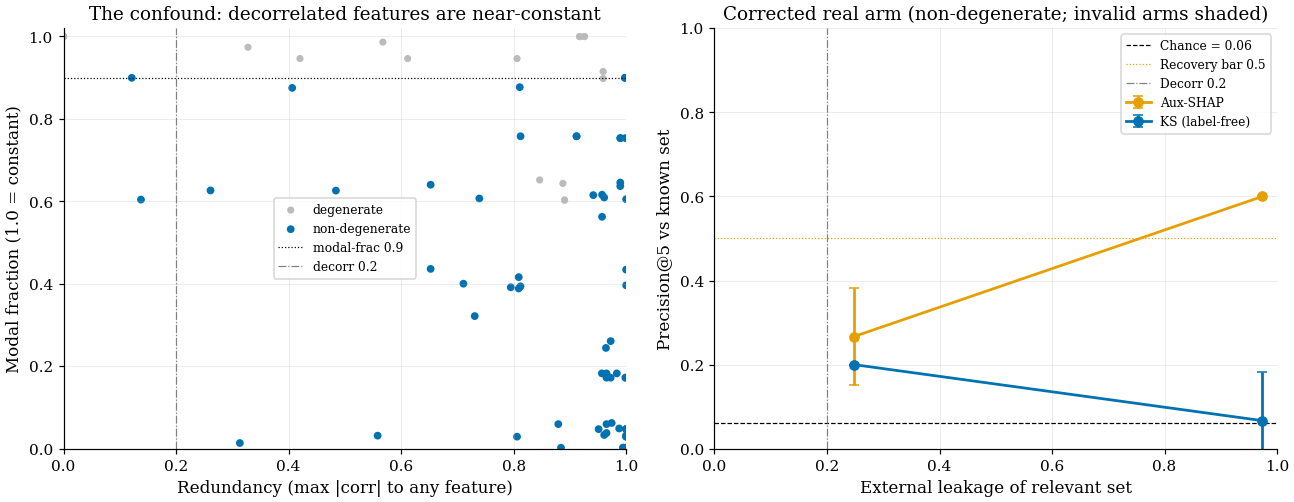

In [9]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 4.8))

axA.scatter(REDUNDANCY[~NONDEGEN], MODAL_FRAC[~NONDEGEN], s=22, c='#BBBBBB',
            label='degenerate', edgecolor='none')
axA.scatter(REDUNDANCY[NONDEGEN], MODAL_FRAC[NONDEGEN], s=26, c='#0072B2',
            label='non-degenerate', edgecolor='none')
axA.axhline(MODAL_MAX, ls=':', color='black', lw=0.8, label=f'modal-frac {MODAL_MAX}')
axA.axvline(REAL_DECORR_MAX, ls='-.', color='grey', lw=0.8, label=f'decorr {REAL_DECORR_MAX}')
axA.set_xlabel('Redundancy (max |corr| to any feature)')
axA.set_ylabel('Modal fraction (1.0 = constant)')
axA.set_xlim(0, 1.0); axA.set_ylim(0, 1.02)
axA.set_title('The confound: decorrelated features are near-constant')
axA.legend(fontsize=8)

valid = {lv: (meta(lv, 'aux_recall') >= RECALL_MIN
              and BALANCE_BAND[0] <= meta(lv, 'balance') <= BALANCE_BAND[1])
         for lv in ['nd_low', 'nd_high']}
xr = [leak_nd_low, leak_nd_high]
for m in ['aux_shap', 'ks']:
    ms = [agg('nd_low', m)[0], agg('nd_high', m)[0]]
    es = [agg('nd_low', m)[1], agg('nd_high', m)[1]]
    axB.errorbar(xr, ms, yerr=es, marker='o', capsize=3, color=METHOD_COLOR[m],
                 label=('Aux-SHAP' if m == 'aux_shap' else 'KS (label-free)'))
axB.axhline(CHANCE, ls='--', color='black', lw=0.8, label=f'Chance = {CHANCE:.2f}')
axB.axhline(RECOVER_MIN, ls=':', color='#E69F00', lw=0.8, label=f'Recovery bar {RECOVER_MIN}')
axB.axvline(REAL_DECORR_MAX, ls='-.', color='grey', lw=0.8, label=f'Decorr {REAL_DECORR_MAX}')
for lv, x in [('nd_low', leak_nd_low), ('nd_high', leak_nd_high)]:
    if not valid[lv]:
        axB.axvspan(max(x - 0.03, 0), x + 0.03, color='red', alpha=0.07)
axB.set_xlabel('External leakage of relevant set')
axB.set_ylabel(f'Precision@{K_PRIMARY} vs known set')
axB.set_xlim(0, 1.0); axB.set_ylim(0, 1.0)
axB.set_title('Corrected real arm (non-degenerate; invalid arms shaded)')
axB.legend(fontsize=8)

fig.tight_layout(); save_figure(fig, '07h_degeneracy_diagnostic'); plt.show()

## 9. Pre-registered verdict (D024)

In [10]:
nd_count = int(NONDEGEN.sum())
low_valid = (meta('nd_low', 'aux_recall') >= RECALL_MIN
             and BALANCE_BAND[0] <= meta('nd_low', 'balance') <= BALANCE_BAND[1])
real_reached = (not np.isnan(leak_nd_low)) and (leak_nd_low <= REAL_DECORR_MAX)
shap_nd_low = agg('nd_low', 'aux_shap')[0]
real_recovers = shap_nd_low >= RECOVER_MIN

if nd_count < GT_SIZE:
    verdict = 'NO-NONDEGENERATE-SET'
elif not real_reached:
    verdict = 'COMPOUND-STRUCTURAL-BLOCK'
elif real_reached and not low_valid:
    verdict = 'INCONCLUSIVE-DEGENERATE'
elif real_reached and low_valid and real_recovers:
    verdict = 'REAL-POSITIVE-POLE'
else:
    verdict = 'GENUINE-SECOND-FACTOR'

print('=' * 72)
print('DEGENERACY / REACHABILITY VERDICT (D024)  -- precision@%d vs known set' % K_PRIMARY)
print('=' * 72)
print(f'  non-degenerate features: {nd_count} of {N_FEATURES}')
print(f'  decorrelated non-degenerate set reachable (leak {leak_nd_low:.3f} <= {REAL_DECORR_MAX}): {real_reached}')
print(f'  nd_low construction valid (recall {meta("nd_low","aux_recall"):.2f} >= {RECALL_MIN}, '
      f'balance {meta("nd_low","balance"):.2f}): {low_valid}')
print(f'  nd_low aux-SHAP = {shap_nd_low:.3f}  (chance {CHANCE:.3f}, recovery bar {RECOVER_MIN})')
print(f'  nd_high (correlated) aux-SHAP = {agg("nd_high","aux_shap")[0]:.3f} '
      f'(leak {leak_nd_high:.3f}, valid {valid["nd_high"]})')
print('-' * 72)
print(f'--> VERDICT: {verdict}')
MSG = {
    'NO-NONDEGENERATE-SET':
        'Fewer than k non-degenerate features exist; no informative relevant set can even '
        'be formed. Localization is structurally impossible on CICIDS.',
    'COMPOUND-STRUCTURAL-BLOCK':
        'No decorrelated AND non-degenerate set exists: informative features are collinear '
        '(non-identifiable), decorrelated features are near-constant (unlearnable). '
        'Localization fails on CICIDS for a compound, measurable reason. Positive search '
        'closed; diagnostic is two-dimensional (redundancy AND distributional health).',
    'INCONCLUSIVE-DEGENERATE':
        'A low-leakage non-degenerate set was selected but its label is still not learnable '
        '-- tighten the non-degeneracy filter and re-run before concluding.',
    'REAL-POSITIVE-POLE':
        'A decorrelated non-degenerate set exists and aux-SHAP recovers it with a valid '
        'model. A genuine real-data positive regime survives, with the identifiability '
        'diagnostic.',
    'GENUINE-SECOND-FACTOR':
        'A decorrelated non-degenerate set exists, the model learns it (valid recall), yet '
        'aux-SHAP fails. This is real evidence of a second factor beyond correlation and '
        'qualifies the synthetic mechanism on real data; investigate.',
}[verdict]
print('   ' + MSG)

DEGENERACY / REACHABILITY VERDICT (D024)  -- precision@5 vs known set
  non-degenerate features: 63 of 82
  decorrelated non-degenerate set reachable (leak 0.248 <= 0.2): False
  nd_low construction valid (recall 0.99 >= 0.7, balance 0.50): True
  nd_low aux-SHAP = 0.267  (chance 0.061, recovery bar 0.5)
  nd_high (correlated) aux-SHAP = 0.600 (leak 0.974, valid True)
------------------------------------------------------------------------
--> VERDICT: COMPOUND-STRUCTURAL-BLOCK
   No decorrelated AND non-degenerate set exists: informative features are collinear (non-identifiable), decorrelated features are near-constant (unlearnable). Localization fails on CICIDS for a compound, measurable reason. Positive search closed; diagnostic is two-dimensional (redundancy AND distributional health).


In [11]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'seeds': SEEDS, 'rel_size': REL_SIZE, 'chance': CHANCE,
    'modal_max': MODAL_MAX, 'min_distinct': MIN_DISTINCT,
    'nondegenerate_count': nd_count,
    'nondegen_count_by_modal': {str(t): int(((MODAL_FRAC <= t) & (N_DISTINCT >= MIN_DISTINCT)).sum())
                                for t in MODAL_GRID},
    's2_07g_features': [FEATURE_COLS[int(i)] for i in S2_07g],
    's2_07g_modal_frac': [float(MODAL_FRAC[int(i)]) for i in S2_07g],
    'demo_label_balance': float(y_demo.mean()),
    'nd_low_features': [FEATURE_COLS[int(i)] for i in S_nd_low],
    'leak_nd_low': leak_nd_low, 'leak_nd_high': leak_nd_high,
    'nd_low_recall': meta('nd_low', 'aux_recall'), 'nd_low_balance': meta('nd_low', 'balance'),
    'nd_low_shap': shap_nd_low, 'nd_high_shap': agg('nd_high', 'aux_shap')[0],
    'real_reached': bool(real_reached), 'low_valid': bool(low_valid),
    'verdict': verdict,
    'syn_mechanism_07g': {'syn_low': SYN_LOW_07G, 'syn_trend': SYN_TREND_07G, 'confirmed': MECH_07G},
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

log_finding(
    finding_id='F012',
    title='Degeneracy diagnostic + non-degeneracy-controlled real localization arm',
    context='03_phase1_cicids/07h_degeneracy_diagnostic',
    what_we_did=(
        'Resolved 07g\'s invalid real-low arm (NaN recall). Computed per-feature degeneracy '
        '(modal fraction, distinct values), reproduced 07g\'s lowest-redundancy set to show '
        'its degenerate label, then re-ran the real concept arm selecting lowest- vs '
        'highest-redundancy sets from NON-DEGENERATE features only (vary correlation, hold '
        'non-degeneracy fixed), gating each on aux-recall and label balance. D024.'
    ),
    what_we_found=(
        'Verdict: ' + verdict + '. Of %d features, %d are non-degenerate (modal<=%.2f, '
        'distinct>=%d). 07g\'s lowest-redundancy set had modal fractions up to %.3f and a '
        'label balance of %.4f (the NaN-recall cause). Lowest-redundancy non-degenerate '
        'set: external leakage %.3f (decorrelated reachable: %s); aux-SHAP %.3f '
        '(recall %.2f, balance %.2f, chance %.3f). Correlated non-degenerate set: '
        'leakage %.3f, aux-SHAP %.3f. 07g synthetic mechanism confirmed (rho=0 SHAP=%s).'
        % (N_FEATURES, nd_count, MODAL_MAX, MIN_DISTINCT,
           float(np.max(MODAL_FRAC[S2_07g])), float(y_demo.mean()),
           leak_nd_low, str(bool(real_reached)), shap_nd_low,
           meta('nd_low', 'aux_recall'), meta('nd_low', 'balance'), CHANCE,
           leak_nd_high, agg('nd_high', 'aux_shap')[0], str(SYN_LOW_07G))
    ),
    why_it_matters=(
        'Determines whether explanation localization fails on CICIDS for a compound, '
        'measurable structural reason (informative features collinear; decorrelated '
        'features degenerate) or whether a real decorrelated regime exists. Closes the '
        'positive-shaped search and supplies the two-dimensional pre-deployment diagnostic '
        '(redundancy AND distributional health) for the evaluation-framework contribution.'
    ),
)
print('F012 logged. Annotate F011 (07g real-low NaN) and record the call in a hand journal entry.')

Saved /content/drive/MyDrive/phd_thesis/data/processed/phase1_07h_degeneracy.json
[FINDING LOGGED] F012: Degeneracy diagnostic + non-degeneracy-controlled real localization arm
F012 logged. Annotate F011 (07g real-low NaN) and record the call in a hand journal entry.


## 10. What this settles

- **COMPOUND-STRUCTURAL-BLOCK** (expected) — closes the positive search cleanly: on CICIDS,
  informative features are mutually collinear (non-identifiable) and the only decorrelated
  features are near-constant (unlearnable), so no decorrelated-and-informative relevant set
  exists. Combined with the 07g synthetic confirmation, the full causal account is:
  explanation localization *can* work when the target is identifiable (synthetic), and
  *cannot* on real IDS data because the feature geometry forbids an identifiable target.
  The thesis ships a two-dimensional diagnostic and rests on the redundancy benchmark plus
  the evaluation framework.
- **REAL-POSITIVE-POLE** — a narrow but genuine real-data regime survives; report it with
  the diagnostic.
- **GENUINE-SECOND-FACTOR** — the one outcome that reopens a real-data question; would
  qualify the synthetic mechanism and warrant a focused follow-up before any positive claim.

Whatever the tier, this is the end of the positive-shaped search. Next: annotate F011 (07g
real-low was construction-invalid; corrected reading = mechanism confirmed synthetically,
real reachability resolved here), update the regime map's governing-variable row to
*identifiability under feature redundancy, gated by distributional health*, then move to
breadth (UNSW + XGBoost) with per-dataset redundancy + degeneracy measurement as a
first-class protocol step.

Record the call by hand:

In [12]:
# add_journal_entry(
#     title='Notebook 07h degeneracy / reachability verdict',
#     body='...the confound (decorrelated features are near-constant), the corrected real '
#          'arm result, the verdict tier, and the correction it forces on 07g/F011.',
# )